**ML Curiosity Corner** $-$ Short experiments exploring interesting behaviour in machine learning systems.

---

# Extreme Examples: Finding Patterns in Pure Noise

---

## 1. A little intro

Machine learning models are extremely good at finding patterns; sometimes a little *too* good.

One of the most important lessons in data science is that **models will happily find structure even when none exists** — especially when the data are high-dimensional.

In this short experiment, we'll deliberately construct a completely meaningless dataset and see how easily a model can still appear to perform well. The goal isn't to build a useful model. It's simply to demonstrate an uncomfortable truth:

> If you're not careful, machine learning can look convincing even when **it might be learning something from nothing**.

Let's start with a very visual example and in other notebooks we'll explore numerical features.

---

## 2. The experiment

We generate small black-and-white "images" where each pixel is completely random (0 or 1, with equal probability). Each image is therefore pure noise — like static on old cathode-ray tube televisions.

Each image has $32 \times 32 = 1024$ pixels, meaning the model receives **1024-dimensional
noise** for every example. We'll create 200 images in total, some examples of which are below:

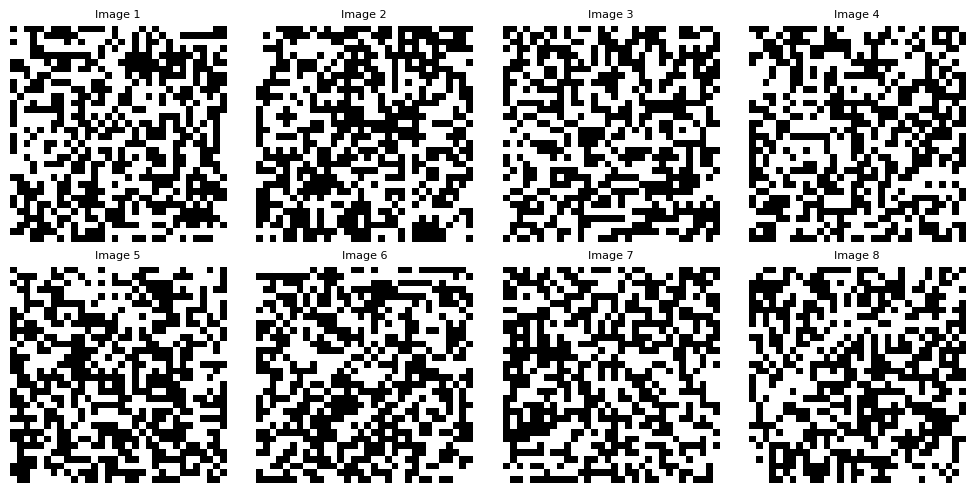

In [ ]:
# --- Example "static images" ---

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

def make_noise_images(n_samples=8, size=32, random_state=0):
    rng = np.random.RandomState(random_state)
    X = rng.randint(0, 2, size=(n_samples, size, size))
    return X

# generate 8 noise images
imgs = make_noise_images(n_samples=8, size=32, random_state=42)

plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imgs[i], cmap='gray', interpolation='nearest')
    plt.axis('off')
    plt.title(f"Image {i+1}", fontsize=8)

plt.tight_layout()
plt.show()


We're now going to **randomly assign** 100 of those images to one group, and 100 to another.

We then set an algorithm (in this case a logistic regression) to learn rules to distinguish the groups.

And then, another 19 times, we're going to continue randomly assigning those 200 images to two groups, i.e., the groupings are likely to be **different each time**.

And after that, we see how the models performed overall.

---

## 3. The results

What happened? **The model learned each mapping extremely well on the training data.**

With 1024 random features per image, there are countless accidental patterns the model can exploit. Even though the images contain no real structure, the classifier can find configurations of pixels that *coincidentally* correlate with the assigned labels.

From the model’s perspective, these coincidental patterns look like genuine rules. **But the test accuracy stays at chance.**

As soon as the model sees new noise images, the accidental patterns disappear. The rules it learned do not generalise — because they were never real in the first place.

This can be seen in the following plots:

In [ ]:
# --- Run experiment ---
def run_noise_experiment(size=32, n_samples=200, repeats=20):
    results = []
    for seed in range(repeats):
        rng = np.random.RandomState(seed)
        
        X = rng.randint(0, 2, size=(n_samples, size * size))
        y = rng.randint(0, 2, size=n_samples)
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, stratify=y, random_state=seed
        )
        
        clf = LogisticRegression(max_iter=2000, solver="liblinear")
        clf.fit(X_train, y_train)
        
        results.append({
            "seed": seed,
            "train_acc": clf.score(X_train, y_train),
            "test_acc": clf.score(X_test, y_test),
        })
    return results

results = run_noise_experiment()


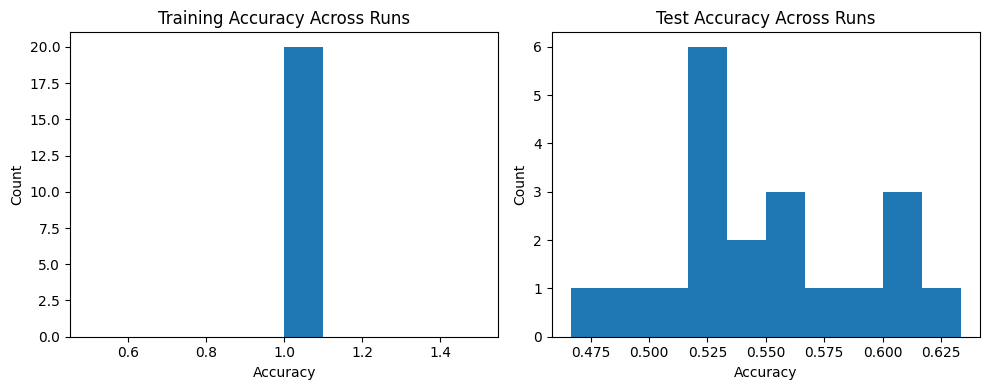

In [ ]:
# --- Plot results ---

train_acc = [r["train_acc"] for r in results]
test_acc = [r["test_acc"] for r in results]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(train_acc, bins=10)
plt.title("Training Accuracy Across Runs")
plt.xlabel("Accuracy"); plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(test_acc, bins=10)
plt.title("Test Accuracy Across Runs")
plt.xlabel("Accuracy"); plt.ylabel("Count")

plt.tight_layout()
plt.show()



---

## 4. Key takeaway

Our simple visual demonstration shows how:

- **Noise in high dimensions always contains accidental structure**

- **Machine learning models are designed to discover and exploit structure in data**

- **Training accuracy can be very high even when no real pattern exists**

- **Generalisation is the only true test of learning**

This intuition carries directly into numerical datasets. High-dimensional random data behaves
just like these static images: full of coincidences that models can memorise but not trust.

The key lesson is simple: **high dimensional data makes accidental patterns easy to find.**

Without careful validation, models can appear to perform well even when they are learning from noise.

This is why strong evaluation practices — proper train/test splits, cross-validation, and realistic test data — are essential in real-world machine learning.

---